In [5]:
# IMPORTS
import os
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from tqdm import tqdm

In [6]:
# CONSTANTS
plt.style.use('dark_background')

EXAMPLES_FOR_PLOT = 5
LATENT_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 100
DEVICE = "cpu"

if torch.cuda.is_available():
    DEVICE = "cuda"

LOCAL_DATA_PATH = "../.local_data"
DATASET_PATH = f"{LOCAL_DATA_PATH}/datasets"
WEIGHTS_PATH = f"{LOCAL_DATA_PATH}/model_weights"
LOGS_PATH = f"{LOCAL_DATA_PATH}/logs"
os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(WEIGHTS_PATH, exist_ok=True)
os.makedirs(LOGS_PATH, exist_ok=True)

In [7]:
# DATA PREP
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Lambda(lambda t: t/255) # TODO normal scaling
])
train_data = torchvision.datasets.CelebA(DATASET_PATH, download=True, transform=transform, split="train")
test_data = torchvision.datasets.CelebA(DATASET_PATH, download=True, transform=transform, split="test")

train_dataloader = DataLoader(train_data, BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, BATCH_SIZE, shuffle=False)

# getting EXAMPLES_FOR_PLOT examples for plotting, TODO rewrite
examples = None
for X, _ in test_dataloader:
    examples = X[:EXAMPLES_FOR_PLOT, :].to(DEVICE)
    break

In [8]:
# MODEL

class VAE(nn.Module):
    def __init__(self, latent_dim=64, hidden_dim=256):
        super().__init__()
        self.latent_dim = latent_dim
        self.feature_shape = (256, 6, 5)  # channels, height, width

        # Encoder convolutional layers (4 strided conv blocks)
        self.encoder_conv = nn.Sequential(
            # 3 x 218 x 178 -> 32 x 109 x 89
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            # 32 x 109 x 89 -> 64 x 54 x 44
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            # 64 x 54 x 44 -> 128 x 27 x 22
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 128 x 27 x 22 -> 256 x 13 x 11
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool2d((6, 5)),   # force stable bottleneck size
        )

        # Encoder fully-connected layers
        self.encoder_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 5, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Latent space heads
        self.mu_head = nn.Linear(hidden_dim, latent_dim)
        self.logvar_head = nn.Linear(hidden_dim, latent_dim)

        # Decoder fully-connected layer
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256 * 6 * 5),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Decoder upsampling blocks (each: bilinear upsample + conv)
        # Target sizes for each upsampling step
        self.decoder_target_sizes = [(13, 11), (27, 22), (54, 44), (109, 89), (218, 178)]
        # Corresponding convolution blocks (in_ch, out_ch)
        conv_blocks = [
            nn.Sequential(
                nn.Conv2d(256, 128, kernel_size=3, padding=1),
                nn.BatchNorm2d(128),
                nn.LeakyReLU(0.2, inplace=True),
            ),
            nn.Sequential(
                nn.Conv2d(128, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.LeakyReLU(0.2, inplace=True),
            ),
            nn.Sequential(
                nn.Conv2d(64, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.LeakyReLU(0.2, inplace=True),
            ),
            nn.Sequential(
                nn.Conv2d(32, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.LeakyReLU(0.2, inplace=True),
            ),
            nn.Sequential(
                nn.Conv2d(32, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.LeakyReLU(0.2, inplace=True),
            ),
        ]
        self.decoder_blocks = nn.ModuleList(conv_blocks)

        # Final output layer
        self.final_layer = nn.Sequential(
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid(),   # assumes input images scaled to [0,1]
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = self.encoder_fc(x)
        mu = self.mu_head(x)
        logvar = self.logvar_head(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std).to(DEVICE)
        return mu + eps * std

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, *self.feature_shape)
        for target_size, block in zip(self.decoder_target_sizes, self.decoder_blocks):
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)
            x = block(x)
        return self.final_layer(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


class ELBOLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y, y_prim, mu, std):
        # kl = torch.mean(-0.5 * torch.sum(1 + torch.log(std**2) - mu**2 - std**2, dim=1))

        mse_loss = F.mse_loss(y, y_prim)
        kld_loss = torch.mean(-0.5 * torch.sum(1 + std - mu ** 2 - std.exp(), dim=1), dim=0)
        kld_weight = 1

        # kld_loss = torch.mean(-0.5 * torch.sum(1 + log_var - mu ** 2 - log_var.exp(), dim = 1), dim = 0)

        loss = mse_loss + kld_weight * kld_loss
        return mse_loss, kld_loss


  0%|          | 0/312 [00:01<?, ?it/s]


--------- ITERATION 1 ---------
train loss: 0.915351390838623
train kl: 0.6623067855834961
train l2: 0.25304457545280457

test loss: 0.3075178265571594
test kl: 0.05478421598672867
test l2: 0.25273361802101135


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [125.8863..130.34691].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [125.893074..130.28925].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [125.908936..130.191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [125.93549..130.19632].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [125.903656..130.29774].


<Figure size 640x480 with 0 Axes>

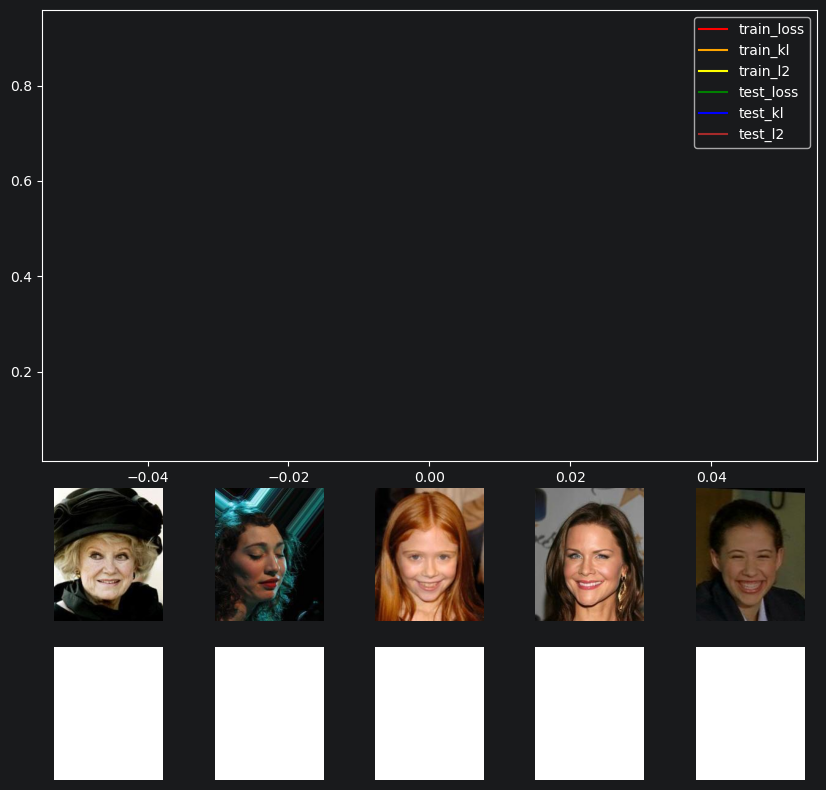

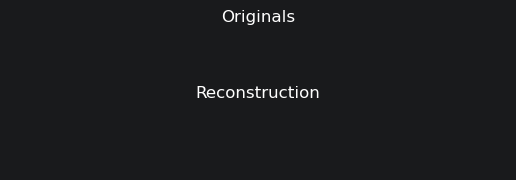

  0%|          | 0/2544 [00:05<?, ?it/s]


KeyboardInterrupt: 

In [14]:
# TRAIN LOOP

model = VAE(LATENT_SIZE).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters())
loss_fn = ELBOLoss()

metrics = defaultdict(list)
# train_l2, train_kl, train_loss
# test_l2, test_kl, test_loss

for epoch in range(1, EPOCHS):
    metrics_epoch = defaultdict(list)

    # train
    model.train()
    for X, _ in tqdm(train_dataloader):
        X = X.to(DEVICE)
        X_prim, mu, std = model.forward(X)
        l2, kl = loss_fn(X, X_prim, mu, std)
        loss = l2 + kl

        loss.backward()
        optimizer.step()
        model.zero_grad()

        # save losses
        metrics_epoch["train_l2"].append(l2.item())
        metrics_epoch["train_kl"].append(kl.item())
        metrics_epoch["train_loss"].append(loss.item())

    # test
    model.eval()
    with torch.no_grad():
        for X, _ in tqdm(test_dataloader):
            X = X.to(DEVICE)
            X_prim, mu, std = model.forward(X)

            l2, kl = loss_fn(X, X_prim, mu, std)
            loss = l2 + kl

            # save losses
            metrics_epoch["test_l2"].append(l2.item())
            metrics_epoch["test_kl"].append(kl.item())
            metrics_epoch["test_loss"].append(loss.item())

    # update metrics dict
    for key, value in metrics_epoch.items():
        mean_value = np.mean(value)
        metrics[key].append(mean_value)

    print(f"--------- ITERATION {epoch} ---------")
    print(f"train loss: {metrics["train_loss"][-1]}")
    print(f"train kl: {metrics["train_kl"][-1]}")
    print(f"train l2: {metrics["train_l2"][-1]}")
    print()
    print(f"test loss: {metrics["test_loss"][-1]}")
    print(f"test kl: {metrics["test_kl"][-1]}")
    print(f"test l2: {metrics["test_l2"][-1]}")

    # plot
    plt.clf()
    x = list(range(epoch))

    fig = plt.figure(figsize=(10, 10))
    gs = GridSpec(5, 5)

    # losses graph
    plt.subplot(gs[0:3, :])
    plt.plot(x, metrics["train_loss"], color="red", label="train_loss")
    plt.plot(x, metrics["train_kl"], color="orange", label="train_kl")
    plt.plot(x, metrics["train_l2"], color="yellow", label="train_l2")

    plt.plot(x, metrics["test_loss"], color="green", label="test_loss")
    plt.plot(x, metrics["test_kl"], color="blue", label="test_kl")
    plt.plot(x, metrics["test_l2"], color="brown", label="test_l2")

    plt.legend()

    # images examples
    examples_prim, _, _ = model.forward(examples)
    for i in range(EXAMPLES_FOR_PLOT):
        ex = (examples[i, :] * 255).permute(1, 2, 0).cpu().squeeze().detach().numpy()
        ex_prim = (examples_prim[i, :] * 255).permute(1, 2, 0).cpu().squeeze().detach().numpy()
        plt.subplot(gs[3, i])
        plt.axis("off")
        plt.imshow(ex)
        plt.subplot(gs[4, i])
        plt.axis("off")
        plt.imshow(ex_prim)

    plt.savefig("celeba_vae.png")
    plt.show()
    torch.save(model.state_dict(), f"./vae_celeba.pt")

        # titles for examples
    plt.subplot(gs[3, :])
    plt.axis("off")
    plt.title("Originals")
    plt.subplot(gs[4, :])
    plt.axis("off")
    plt.title("Reconstruction")

    plt.savefig(f"{LOGS_PATH}/vae_mnist_training.png")
    plt.show()
    torch.save(model.state_dict(), f"{WEIGHTS_PATH}/vae_mnist.pt")